In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

# 1. Importación y tratamiento de datos

In [2]:
clinical = pd.read_csv('.\\src\\data\\hantavirus_clinical.csv')

In [3]:
clinical.nunique()

patient_id                8000
year                        27
country                     17
syndrome                     2
age                         81
sex                          2
symptoms                  7436
incubation_days             38
severity                     4
hospitalized                 2
icu_admission                2
mechanical_ventilation       2
ecmo_used                    2
dialysis                     2
comorbidity                  9
exposure_type                9
outcome                      2
length_of_stay_days         32
dtype: int64

In [4]:
clinical.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   patient_id              8000 non-null   object
 1   year                    8000 non-null   int64 
 2   country                 8000 non-null   object
 3   syndrome                8000 non-null   object
 4   age                     8000 non-null   int64 
 5   sex                     8000 non-null   object
 6   symptoms                8000 non-null   object
 7   incubation_days         8000 non-null   int64 
 8   severity                8000 non-null   object
 9   hospitalized            8000 non-null   int64 
 10  icu_admission           8000 non-null   int64 
 11  mechanical_ventilation  8000 non-null   int64 
 12  ecmo_used               8000 non-null   int64 
 13  dialysis                8000 non-null   int64 
 14  comorbidity             4801 non-null   object
 15  expo

In [5]:
clinical.comorbidity.value_counts(dropna=False)

comorbidity
NaN                       3199
Diabetes                   829
Hypertension               827
Obesity                    640
COPD                       601
Asthma                     500
Cardiovascular Disease     478
Chronic Kidney Disease     394
Immunosuppression          301
Smoking                    231
Name: count, dtype: int64

## 1.1. Selección de variables para el análisis

Para este análisis de los casos y distribución del Hantavirus, se utilizarán variables de la tabla ```clinical```
### Variables
```x_1: length of stay days``` - cuantitativa discreta (int) \
```x_2: country``` - cualitativa, nombre del país \
```x_3: syndrome``` - cualitativa binaria (HPS/HFRS) \
```x_4: age``` - cuantitativa discreta (int) \
```x_5: sex``` - cualitativa binaria (Male/Female) \
```x_6: severity``` - cualitativa, 4 valores: Mild/Moderate/Severe/Critical \
```x_7: outcome``` - cualitativa binaria (Recovered/Deceased) \
```x_8: comorbidity``` cualitativa indicadora de condiciones que afecten adicionalmente a la salud del paciente, transformada a una variable binaria booleana.


In [6]:
df_hantav = clinical[["length_of_stay_days", "country", "syndrome", "age", "sex", "severity", "outcome"]].copy()
df_hantav["comorbidity"] = clinical.comorbidity.notna() # Transformación a una variable binaria booleana para considerar los nulos como datos estadísticos

In [7]:
print(df_hantav.info(), any([any(df_hantav.loc[index].isna()) for index in df_hantav.index]), sep = "\n") # no hay nulos
df_hantav.sample(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   length_of_stay_days  8000 non-null   int64 
 1   country              8000 non-null   object
 2   syndrome             8000 non-null   object
 3   age                  8000 non-null   int64 
 4   sex                  8000 non-null   object
 5   severity             8000 non-null   object
 6   outcome              8000 non-null   object
 7   comorbidity          8000 non-null   bool  
dtypes: bool(1), int64(2), object(5)
memory usage: 445.4+ KB
None
False


,length_of_stay_days,country,syndrome,age,sex,severity,outcome,comorbidity
1528,13,Slovenia,HFRS,33,Male,Moderate,Recovered,False
4601,9,Finland,HFRS,56,Female,Critical,Deceased,True
6013,11,Paraguay,HPS,43,Male,Severe,Recovered,True


# 2. Análisis Univariante

In [8]:
# Importar las funciones de análisis
from src.utils.funciones import diagramas_barras, boxplot_histograma, histograma_por_categorias, comparar_cualitativas, diagrama_dispersion

### Variables cualitativas

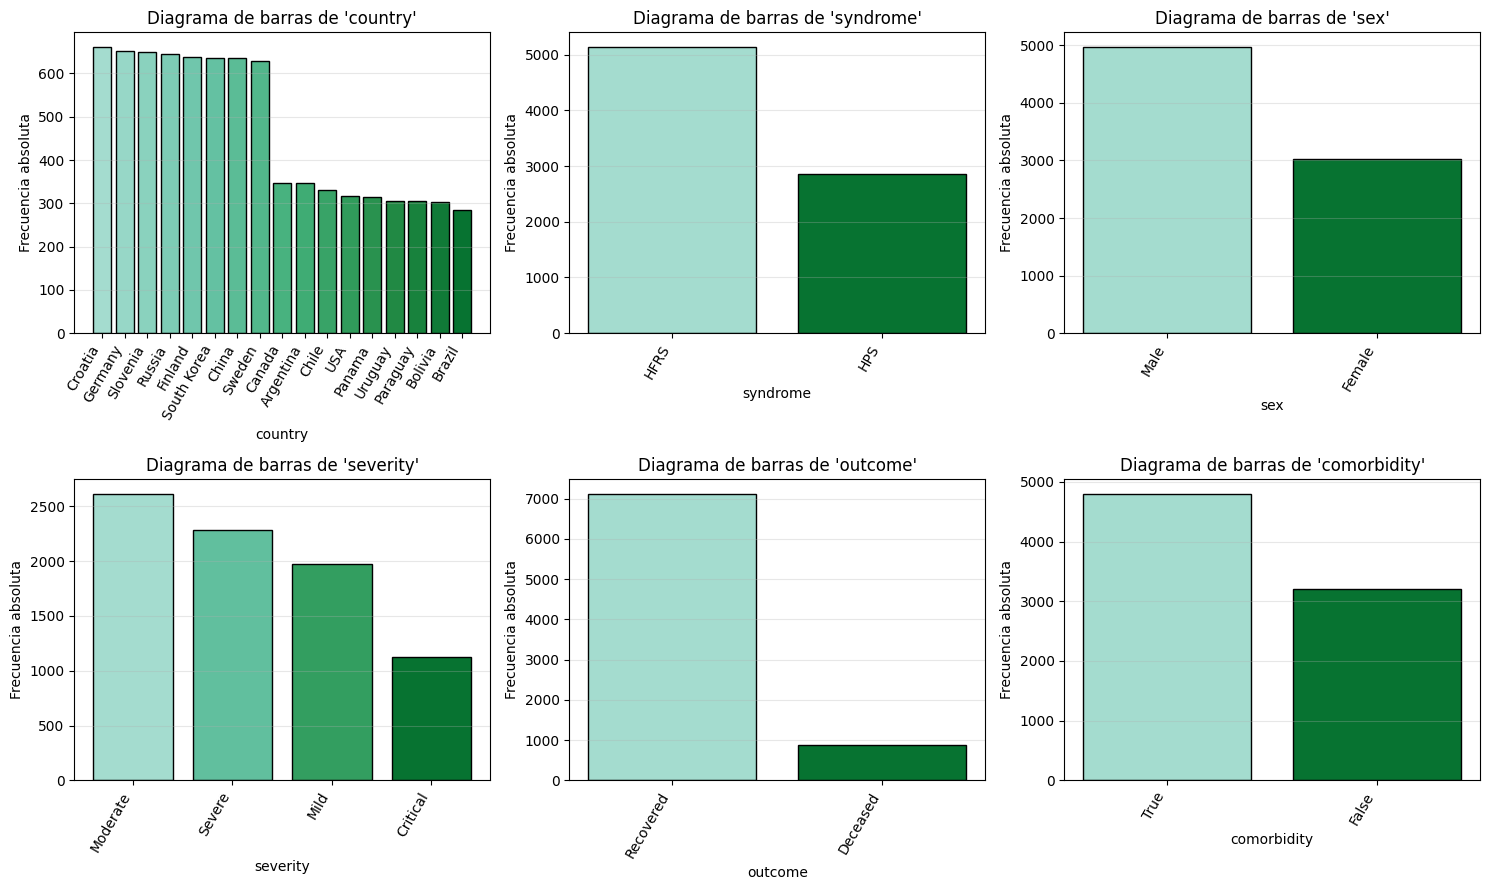

In [9]:
diagramas_barras(df_hantav, ["country", "syndrome", "sex", "severity", "outcome", "comorbidity"])

### Variables cuantitativas
##### · Age:

In [10]:
df_hantav.age.describe()

count    8000.000000
mean       37.599750
std        14.992645
min         5.000000
25%        27.000000
50%        38.000000
75%        48.000000
max        85.000000
Name: age, dtype: float64

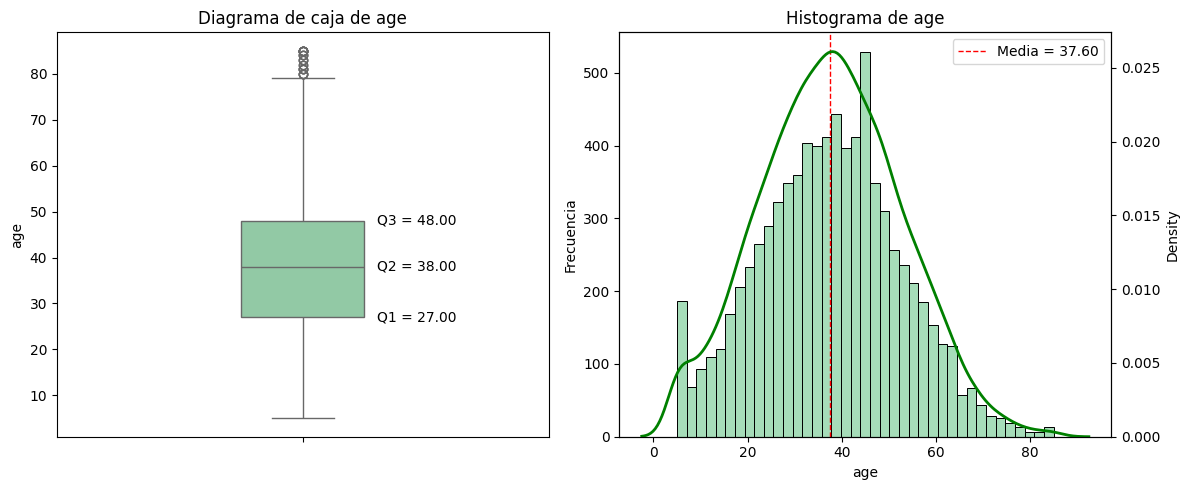

In [11]:
boxplot_histograma(df_hantav,"age")

##### · Length of stay (days):

In [12]:
df_hantav.length_of_stay_days.describe()

count    8000.000000
mean        8.660375
std         6.226606
min         0.000000
25%         3.000000
50%         9.000000
75%        13.000000
max        34.000000
Name: length_of_stay_days, dtype: float64

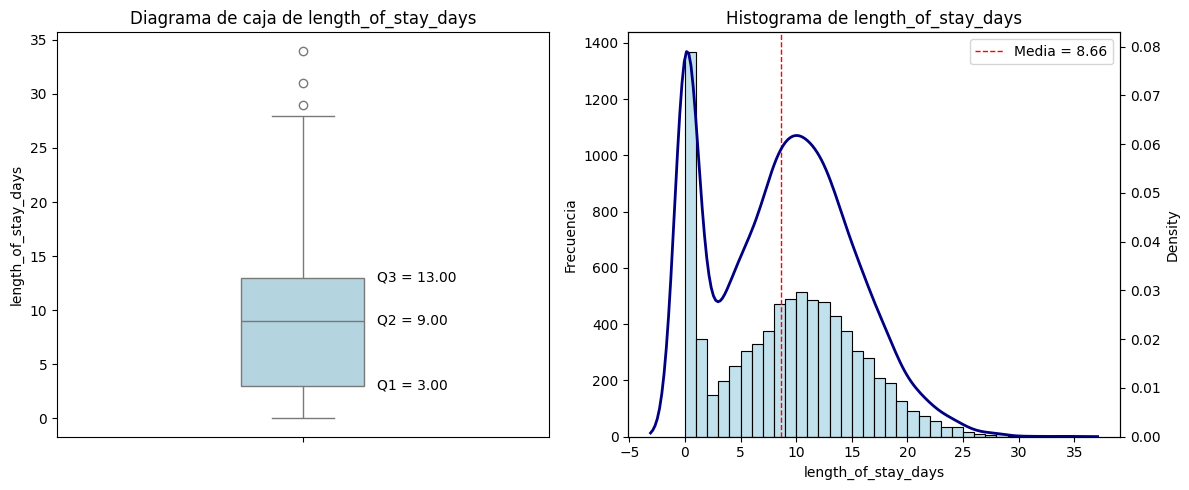

In [13]:
boxplot_histograma(df_hantav, "length_of_stay_days", relleno = "lightblue", color_linea = "navy")

# 3. Análisis Bivariante
## 3.1. Relación de las variables numéricas: **age** y **length of stay** (days)

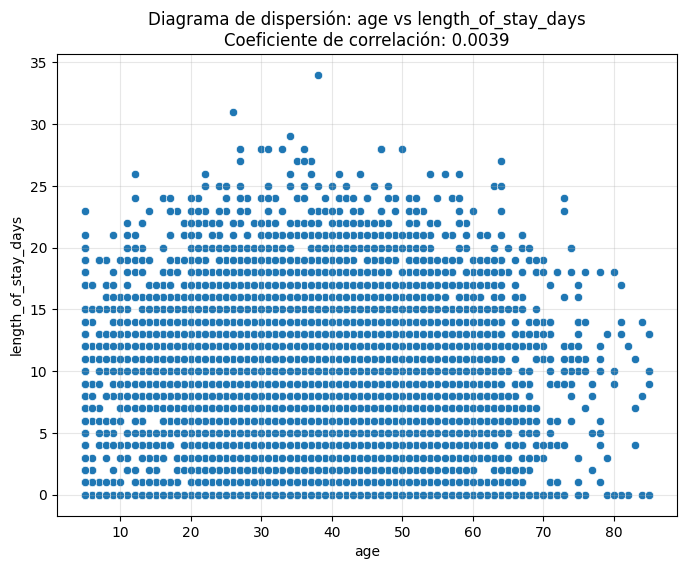

In [14]:
diagrama_dispersion(df_hantav, "age", "length_of_stay_days")

## 3.2. Relación de las variables cuantitativas según categorías cualitativas.
Un análisis explotarorio inicial sobre el que seleccionar las interacciones cualitativas relevantes para las respuestas de estudio.

##### Variable **'age'**:
- By *country*:\
*A valor informativo de la muestra poblacional que representan los datos.*

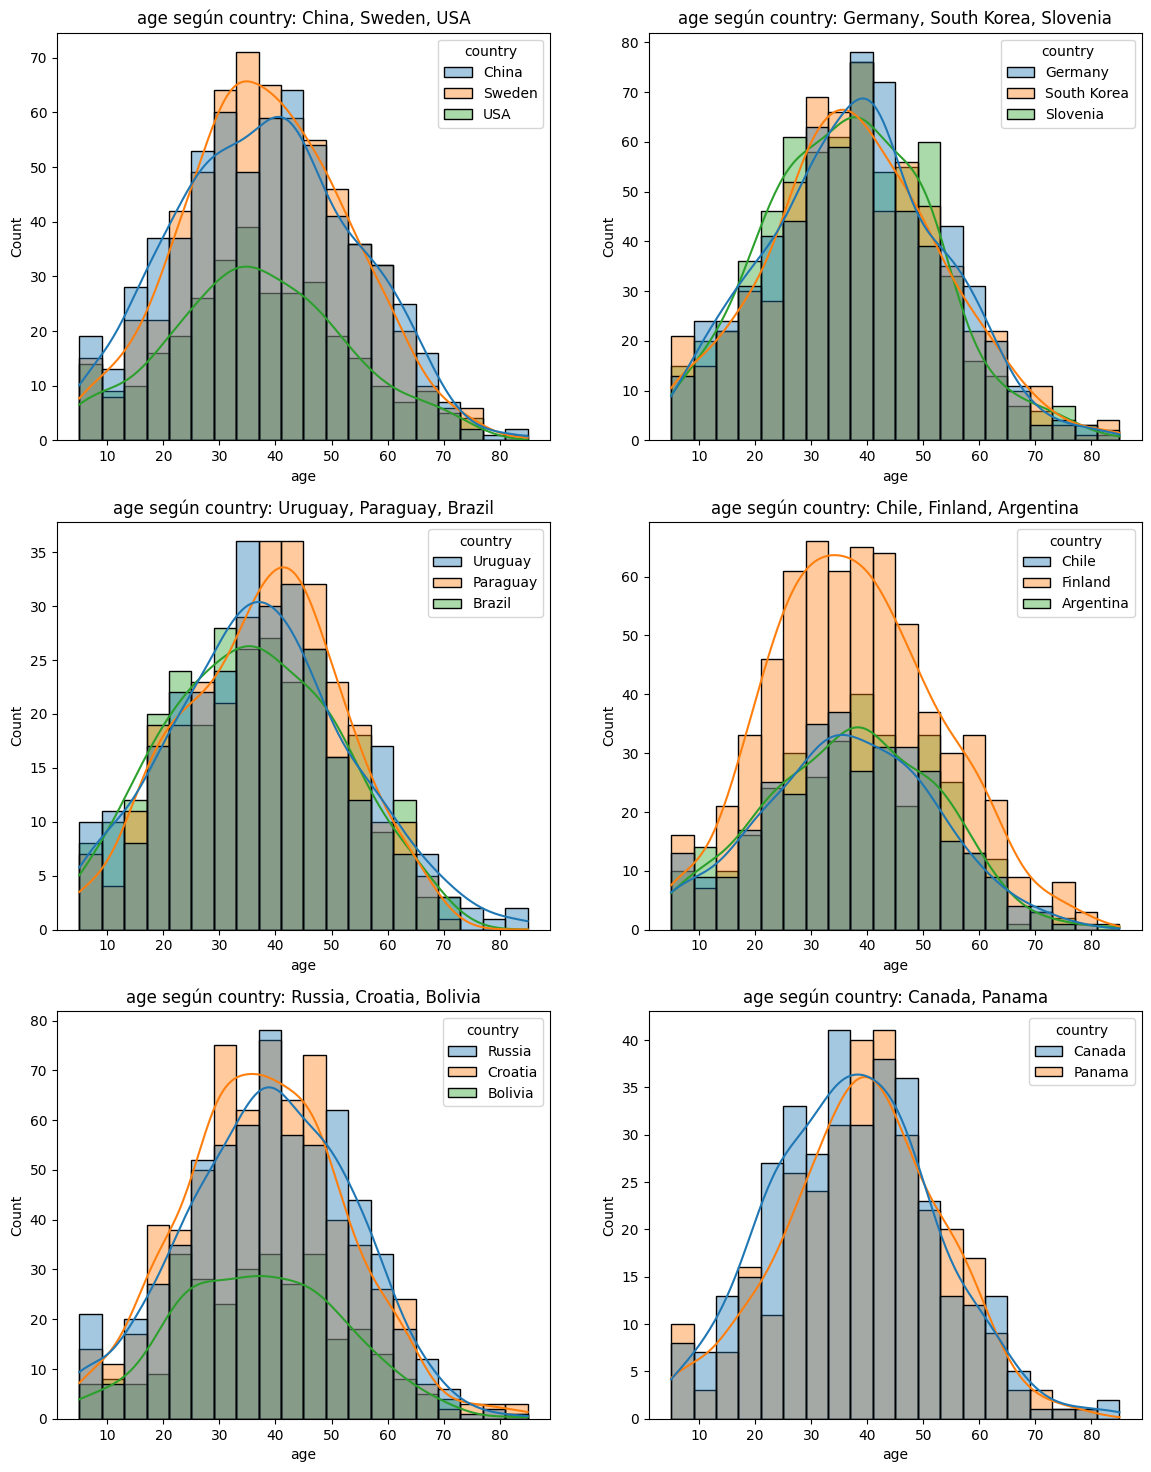

In [15]:
histograma_por_categorias(df_hantav, "age", "country")

- **Age** by *syndrome*:

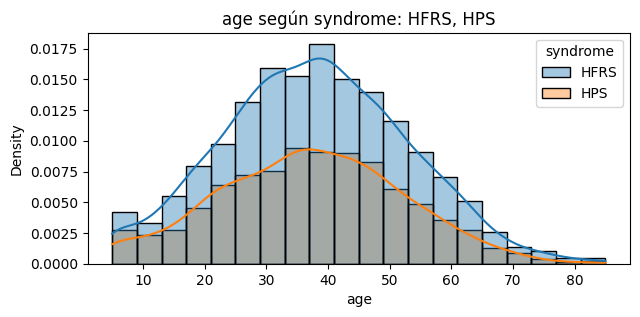

In [16]:
histograma_por_categorias(df_hantav, "age", "syndrome", estadistico="density")

- **Age** by *sex*:

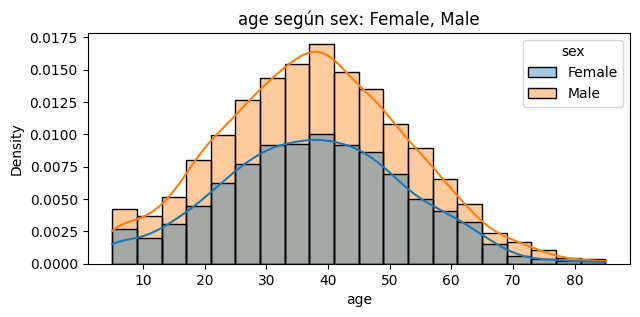

In [17]:
histograma_por_categorias(df_hantav, "age", "sex", estadistico="density")

- **Age** by *severity*:

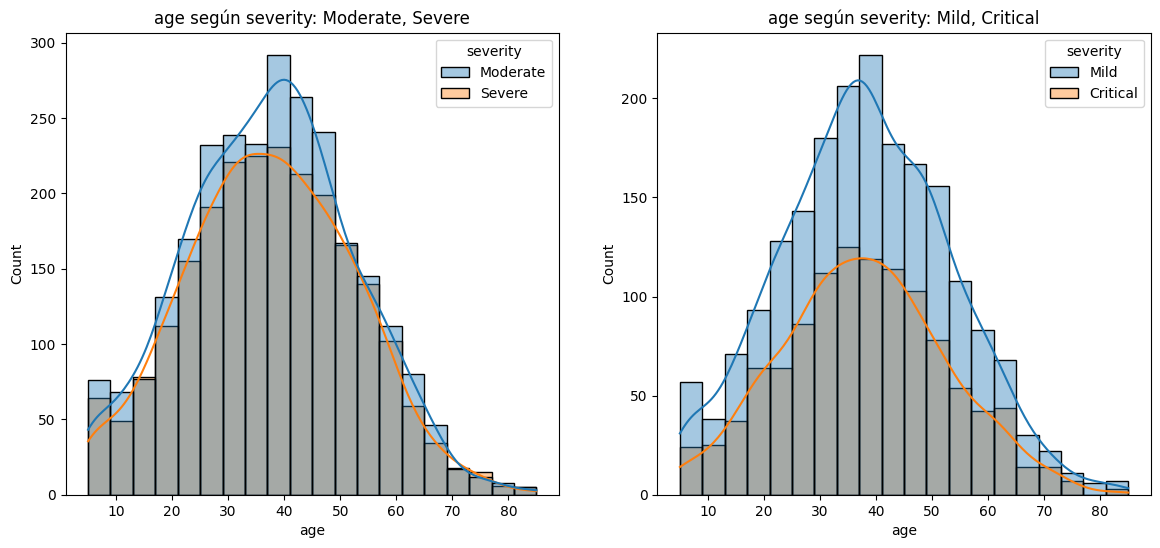

In [18]:
histograma_por_categorias(df_hantav, "age", "severity", max_cat_por_grafico=2)

In [19]:
# ANOVA: comparar las poblaciones de edad según la intensidad de afección.
from scipy import stats
clases = [clase for clase in df_hantav.severity.unique()]
grupos = [df_hantav.loc[df_hantav.severity == clase]["age"] for clase in clases]
print("ANOVA para las poblaciones de age según severity:")
print([float(i) for i in stats.f_oneway(*grupos)])

ANOVA para las poblaciones de age según severity:
[0.7875161396802806, 0.5006821690856242]


- **Age** by *outcome*:

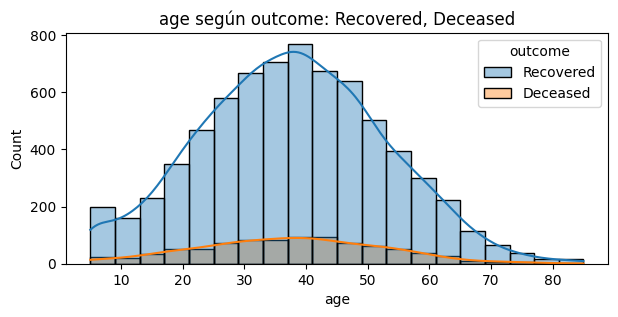

In [20]:
histograma_por_categorias(df_hantav, "age", "outcome")

- **Age** by *comorbidity*:

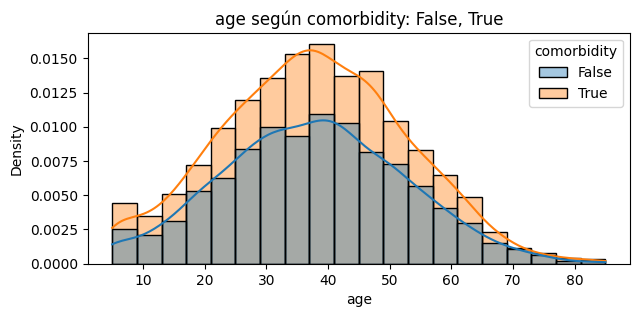

In [21]:
histograma_por_categorias(df_hantav, "age", "comorbidity", estadistico="density")

##### Variable **Length of stay (days)**:
- By *country*:

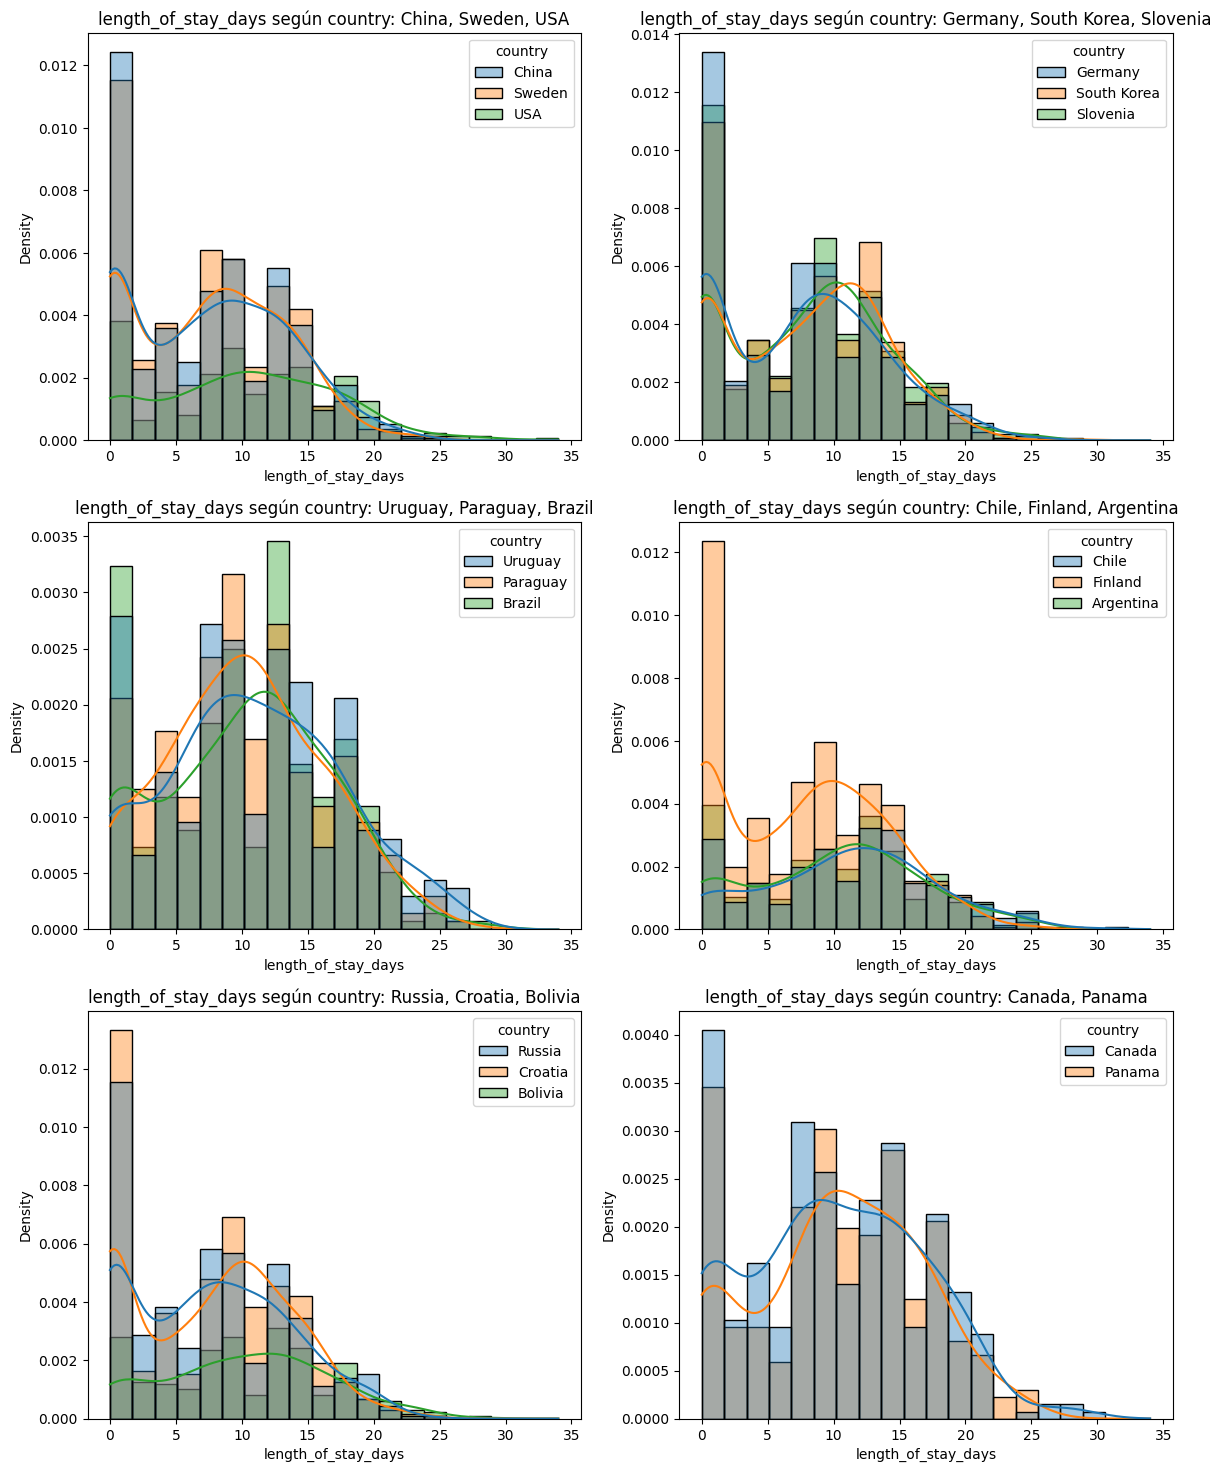

In [22]:
histograma_por_categorias(df_hantav, "length_of_stay_days", "country", estadistico="density")

In [23]:
# ANOVA
clases = [clase for clase in df_hantav.country.unique()]
grupos = [df_hantav.loc[df_hantav.country == clase]["length_of_stay_days"] for clase in clases]
print("ANOVA para las poblaciones de length of stay (days) según country:")
print([float(i) for i in stats.f_oneway(*grupos)])

ANOVA para las poblaciones de length of stay (days) según country:
[24.01085824093926, 4.798635401789578e-70]


- **Length of stay (days)** by *syndrome*:

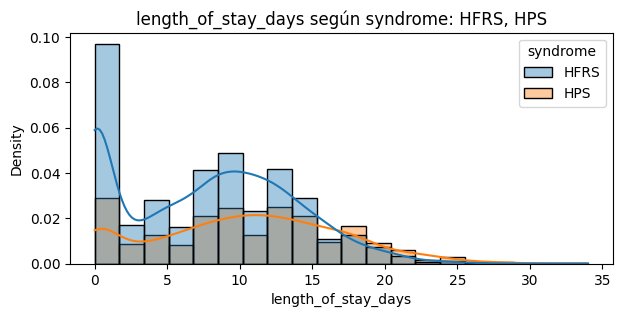

In [24]:
histograma_por_categorias(df_hantav, "length_of_stay_days", "syndrome", estadistico="density")

In [25]:
from scipy.stats import mannwhitneyu
var_cat = "syndrome"
var_num = "length_of_stay_days"
clases = [clase for clase in df_hantav[var_cat].unique()]
grupos = [df_hantav.loc[df_hantav[var_cat] == clase][var_num] for clase in clases]

for i, grupo1 in enumerate(grupos):
    for j in range(i+1, len(grupos)):
        u_stat, p_valor = mannwhitneyu(grupo1, grupos[j])
        print(f"TEST MANN-WHITNEY: poblaciones de {var_num} según {var_cat} {clases[i]} y {clases[j]}.")
        print("Estadístico U:", u_stat)
        print("Valor p:", p_valor, end="\n"*2)

TEST MANN-WHITNEY: poblaciones de length_of_stay_days según syndrome HFRS y HPS.
Estadístico U: 5564636.5
Valor p: 8.304684117306957e-73



- **Length of stay (days)** by *sex*:

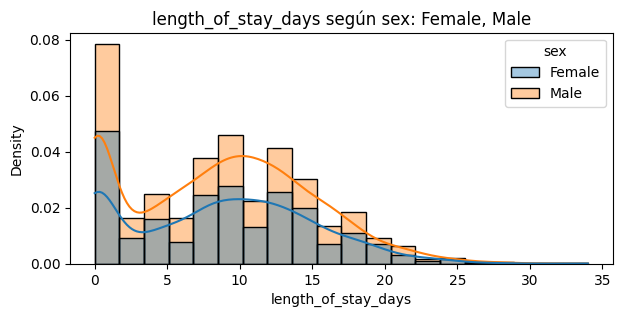

In [26]:
histograma_por_categorias(df_hantav, "length_of_stay_days", "sex", estadistico="density")

In [27]:
var_cat = "sex"
var_num = "length_of_stay_days"
clases = [clase for clase in df_hantav[var_cat].unique()]
grupos = [df_hantav.loc[df_hantav[var_cat] == clase][var_num] for clase in clases]

for i, grupo1 in enumerate(grupos):
    for j in range(i+1, len(grupos)):
        u_stat, p_valor = mannwhitneyu(grupo1, grupos[j])
        print(f"TEST MANN-WHITNEY: poblaciones de {var_num} según {var_cat} {clases[i]} y {clases[j]}.")
        print("Estadístico U:", u_stat)
        print("Valor p:", p_valor, end="\n"*2)

TEST MANN-WHITNEY: poblaciones de length_of_stay_days según sex Female y Male.
Estadístico U: 7562480.0
Valor p: 0.6904904623583615



- **Length of stay (days)** by *severity*:

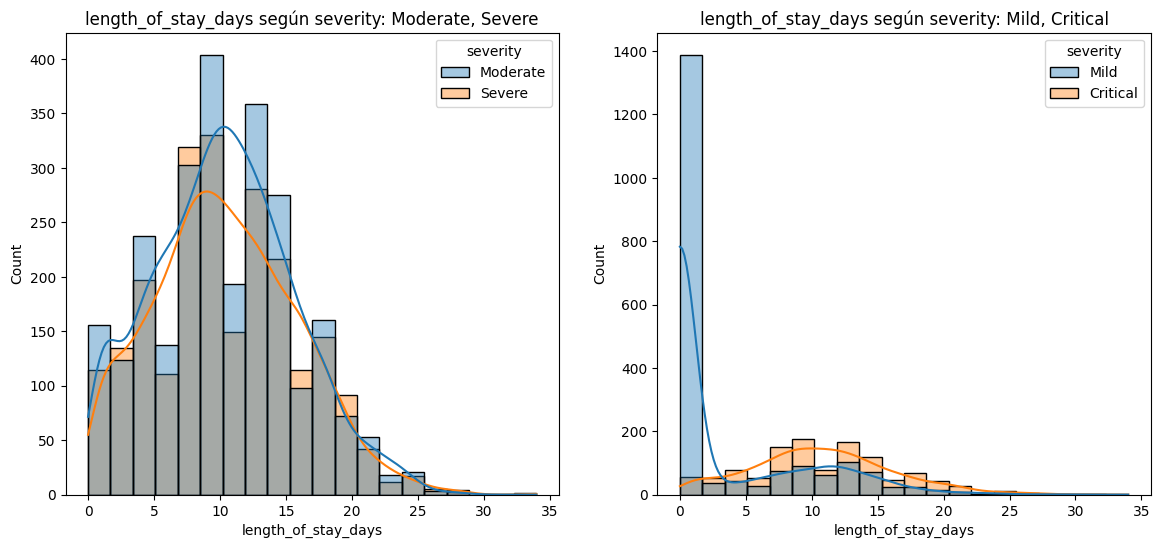

In [28]:
histograma_por_categorias(df_hantav, "length_of_stay_days", "severity", max_cat_por_grafico=2)

In [29]:
var_cat = "severity"
var_num = "length_of_stay_days"
clases = [clase for clase in df_hantav[var_cat].unique()]
grupos = [df_hantav.loc[df_hantav[var_cat] == clase][var_num] for clase in clases]

for i, grupo1 in enumerate(grupos):
    for j in range(i+1, len(grupos)):
        u_stat, p_valor = mannwhitneyu(grupo1, grupos[j])
        print(f"TEST MANN-WHITNEY: poblaciones de {var_num} según {var_cat} {clases[i]} y {clases[j]}.")
        print("Estadístico U:", u_stat)
        print("Valor p:", p_valor, end="\n"*2)

TEST MANN-WHITNEY: poblaciones de length_of_stay_days según severity Moderate y Severe.
Estadístico U: 2971130.0
Valor p: 0.7780624434610359

TEST MANN-WHITNEY: poblaciones de length_of_stay_days según severity Moderate y Mild.
Estadístico U: 4358583.0
Valor p: 0.0

TEST MANN-WHITNEY: poblaciones de length_of_stay_days según severity Moderate y Critical.
Estadístico U: 1423624.0
Valor p: 0.0829261475872782

TEST MANN-WHITNEY: poblaciones de length_of_stay_days según severity Severe y Mild.
Estadístico U: 3808566.0
Valor p: 0.0

TEST MANN-WHITNEY: poblaciones de length_of_stay_days según severity Severe y Critical.
Estadístico U: 1247947.0
Valor p: 0.13115922231814062

TEST MANN-WHITNEY: poblaciones de length_of_stay_days según severity Mild y Critical.
Estadístico U: 333211.5
Valor p: 8.025861926433118e-254



- **Length of stay (days)** by *outcome*:

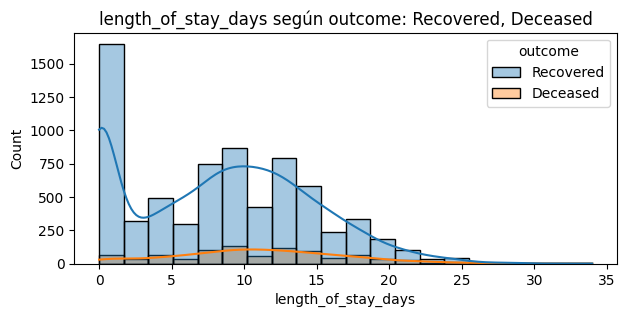

In [30]:
histograma_por_categorias(df_hantav, "length_of_stay_days", "outcome")

In [31]:
var_cat = "outcome"
var_num = "length_of_stay_days"
clases = [clase for clase in df_hantav[var_cat].unique()]
grupos = [df_hantav.loc[df_hantav[var_cat] == clase][var_num] for clase in clases]

for i, grupo1 in enumerate(grupos):
    for j in range(i+1, len(grupos)):
        u_stat, p_valor = mannwhitneyu(grupo1, grupos[j])
        print(f"TEST MANN-WHITNEY: poblaciones de {var_num} según {var_cat} {clases[i]} y {clases[j]}.")
        print("Estadístico U:", u_stat)
        print("Valor p:", p_valor, end="\n"*2)

TEST MANN-WHITNEY: poblaciones de length_of_stay_days según outcome Recovered y Deceased.
Estadístico U: 2387535.5
Valor p: 3.5358556841515032e-31



- **Length of stay (days)** by *comorbidity*:

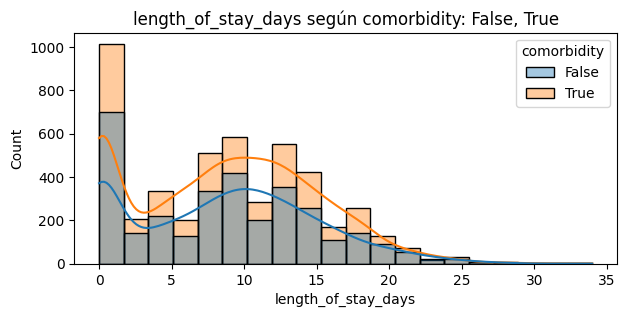

In [32]:
histograma_por_categorias(df_hantav, "length_of_stay_days", "comorbidity")

In [33]:
var_cat = "comorbidity"
var_num = "length_of_stay_days"
clases = [clase for clase in df_hantav[var_cat].unique()]
grupos = [df_hantav.loc[df_hantav[var_cat] == clase][var_num] for clase in clases]

for i, grupo1 in enumerate(grupos):
    for j in range(i+1, len(grupos)):
        u_stat, p_valor = mannwhitneyu(grupo1, grupos[j])
        print(f"TEST MANN-WHITNEY: poblaciones de {var_num} según {var_cat} {clases[i]} y {clases[j]}.")
        print("Estadístico U:", u_stat)
        print("Valor p:", p_valor, end="\n"*2)

TEST MANN-WHITNEY: poblaciones de length_of_stay_days según comorbidity False y True.
Estadístico U: 7597235.5
Valor p: 0.4163488181126871



## 3.3. Análisis comparativo de las variables cualitativas

- Relación entre **'country'** y 'syndrome':

In [34]:
df_hantav.groupby(["syndrome", "country"])["country"].count()

syndrome  country    
HFRS      China          635
          Croatia        662
          Finland        637
          Germany        651
          Russia         645
          Slovenia       650
          South Korea    636
          Sweden         629
HPS       Argentina      346
          Bolivia        303
          Brazil         284
          Canada         348
          Chile          331
          Panama         315
          Paraguay       305
          USA            318
          Uruguay        305
Name: country, dtype: int64

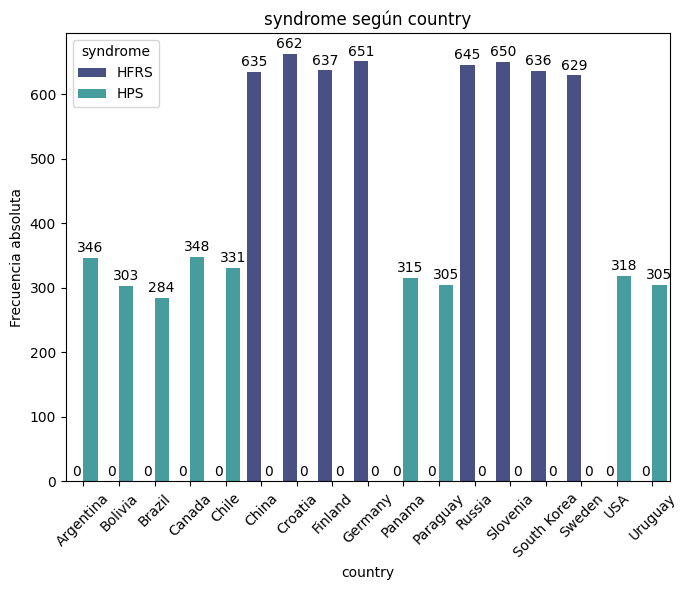

In [35]:
#Vemos que no hay países donde se haya segistrado más de un síndrome.
comparar_cualitativas(df_hantav, "syndrome", "country", ncols=1)

- Relación entre **'severity'** y 'syndrome', 'sex' y 'outcome':

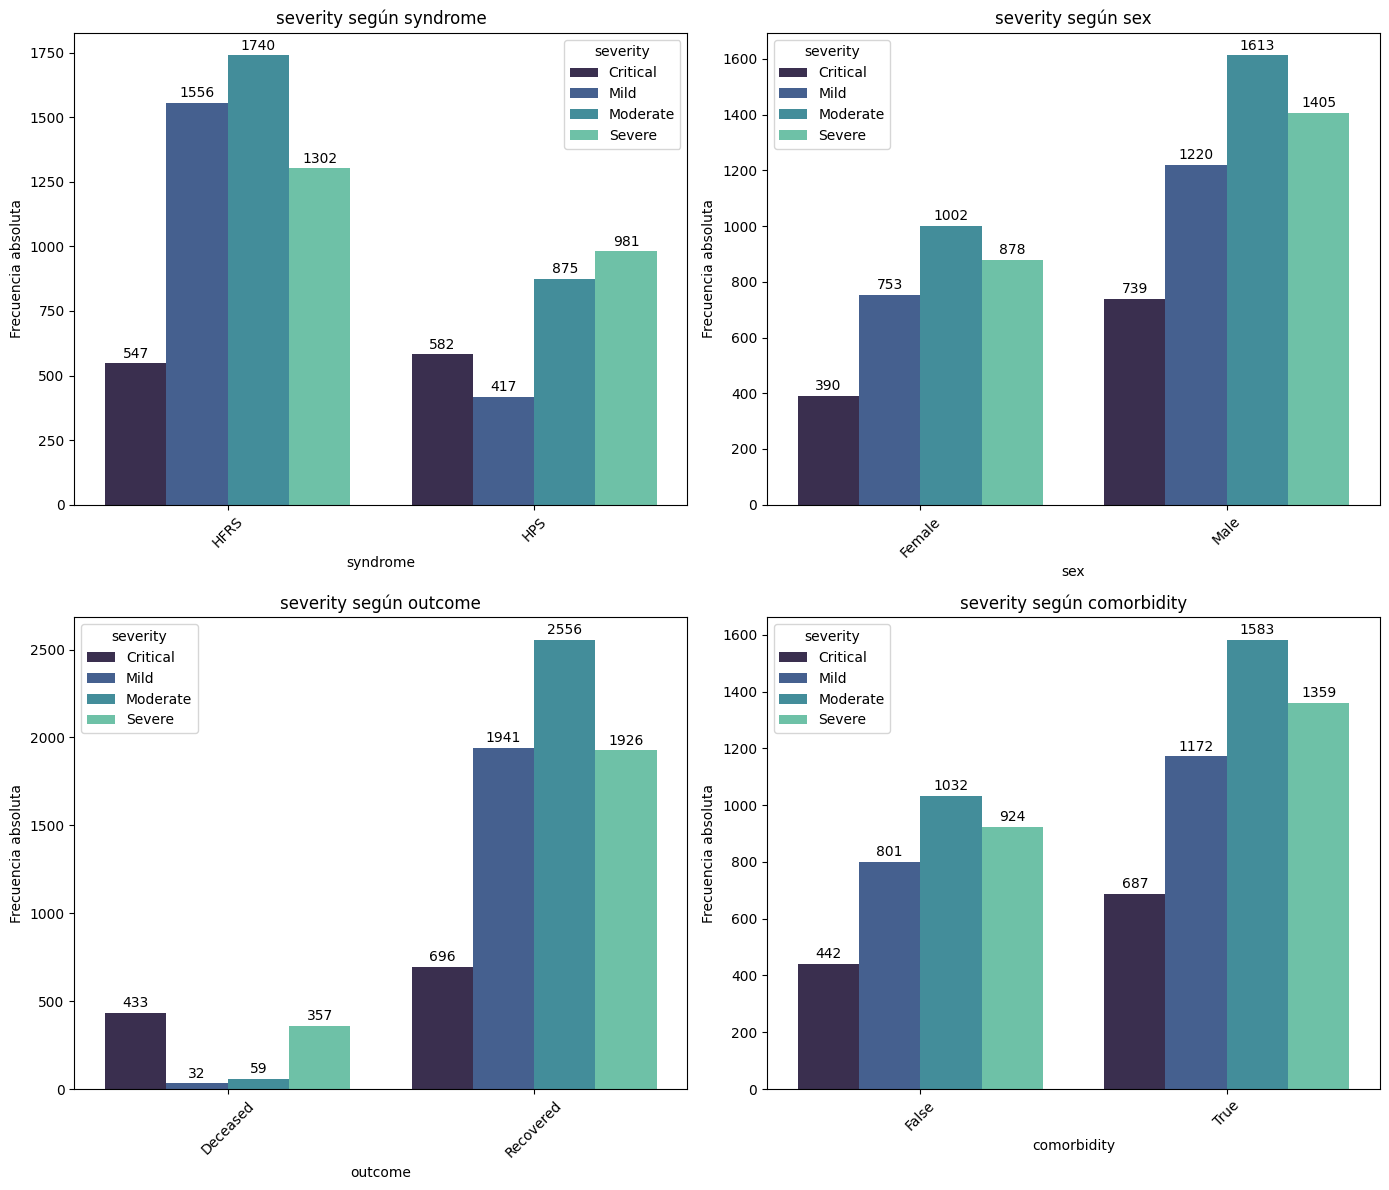

In [ ]:
comparar_cualitativas(df_hantav, "severity", "syndrome", "sex", "outcome", "comorbidity")

In [38]:
# Veamos si las relaciones son significativas:
from scipy.stats import chi2_contingency
vars_comparar = ["syndrome", "sex", "outcome", "comorbidity"]
for variable in vars_comparar:
    tabla_contingencia = pd.crosstab(df_hantav["severity"], df_hantav[variable])

    chi2, p, dof, expected = chi2_contingency(tabla_contingencia)
    print(f"TEST CHI CUADRADO: severity - {variable}")
    print("Valor Chi-Cuadrado:", chi2)
    print("P-Value:", p)
    print("Grados de Libertad:", dof, end="\n"*2)


TEST CHI CUADRADO: severity - syndrome
Valor Chi-Cuadrado: 364.21539300638284
P-Value: 1.2457733758187955e-78
Grados de Libertad: 3

TEST CHI CUADRADO: severity - sex
Valor Chi-Cuadrado: 5.921770132358614
P-Value: 0.11547893269613142
Grados de Libertad: 3

TEST CHI CUADRADO: severity - outcome
Valor Chi-Cuadrado: 1293.1118505251259
P-Value: 4.596454733427409e-280
Grados de Libertad: 3

TEST CHI CUADRADO: severity - comorbidity
Valor Chi-Cuadrado: 1.1589556406416397
P-Value: 0.7628643204213169
Grados de Libertad: 3



- Relación entre **'outcome'** y 'syndrome' y 'comorbidity':

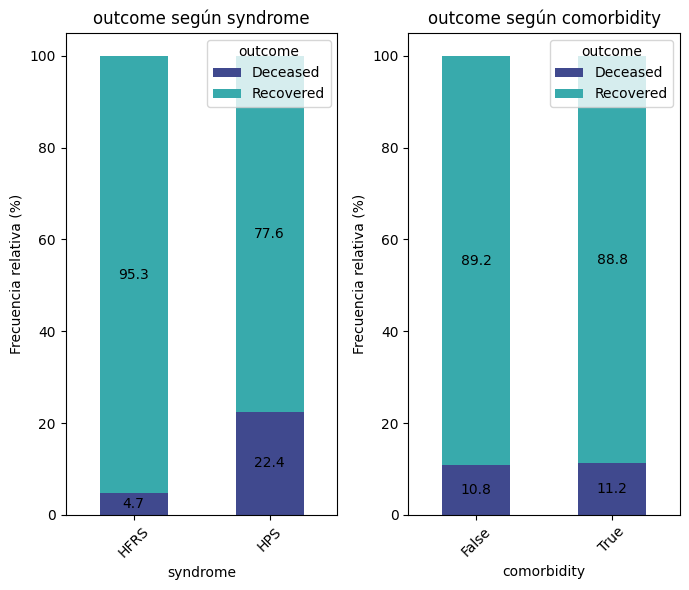

In [39]:
comparar_cualitativas(df_hantav, "outcome", "syndrome", "comorbidity", apilado = True, relativo = True)

In [40]:
# Veamos si las relaciones son significativas:
vars_comparar = ["syndrome", "comorbidity"]
for variable in vars_comparar:
    tabla_contingencia = pd.crosstab(df_hantav["outcome"], df_hantav[variable])

    chi2, p, dof, expected = chi2_contingency(tabla_contingencia)
    print(f"TEST CHI CUADRADO: outcome - {variable}")
    print("Valor Chi-Cuadrado:", chi2)
    print("P-Value:", p)
    print("Grados de Libertad:", dof, end="\n"*2)

TEST CHI CUADRADO: outcome - syndrome
Valor Chi-Cuadrado: 587.3529284237748
P-Value: 9.43379276097909e-130
Grados de Libertad: 1

TEST CHI CUADRADO: outcome - comorbidity
Valor Chi-Cuadrado: 0.3225448345808179
P-Value: 0.570082291297883
Grados de Libertad: 1

